# Mutual Fund Performance Analytics

## 1. Daily Returns

In [23]:
import pandas as pd

# Load NAV history
nav = pd.read_csv("../data/raw/02_nav_history.csv")

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Show first 10 rows
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


## 2. Daily Return Distribution

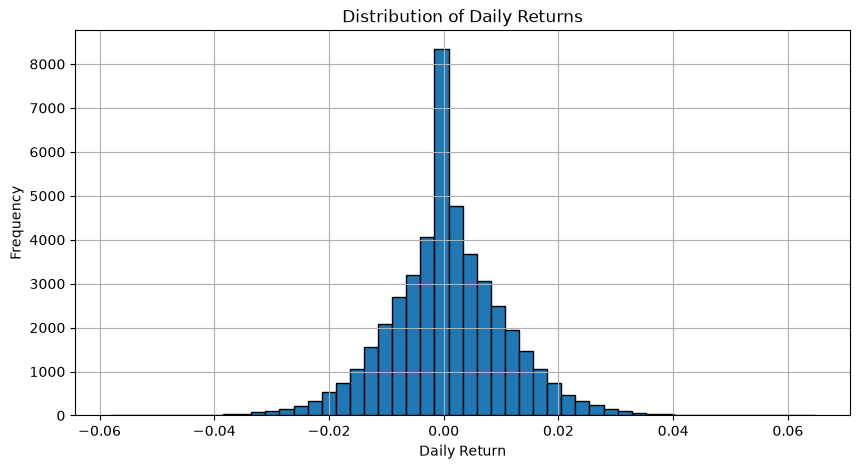

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

nav["daily_return"].hist(
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

### Observation

The daily return distribution is centered around zero with most observations between -2% and +2%. The histogram is approximately bell-shaped with only a few extreme return values, indicating a normal and reasonable distribution of daily returns across the mutual fund schemes.

## 3. CAGR Analysis

In [25]:
import pandas as pd
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

cagr_table = performance[[
    "scheme_name",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]]

cagr_table.head(10)

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43
5,HDFC Top 100 Fund - Regular Plan - Growth,10.94,14.84,11.32
6,HDFC Top 100 Fund - Direct Plan - Growth,11.48,13.38,13.48
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.43,16.58,17.69
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,19.98,15.29,15.85
9,HDFC Short Term Debt Fund - Regular - Growth,6.83,7.37,6.41


## 4. Top 10 Funds by 5-Year CAGR

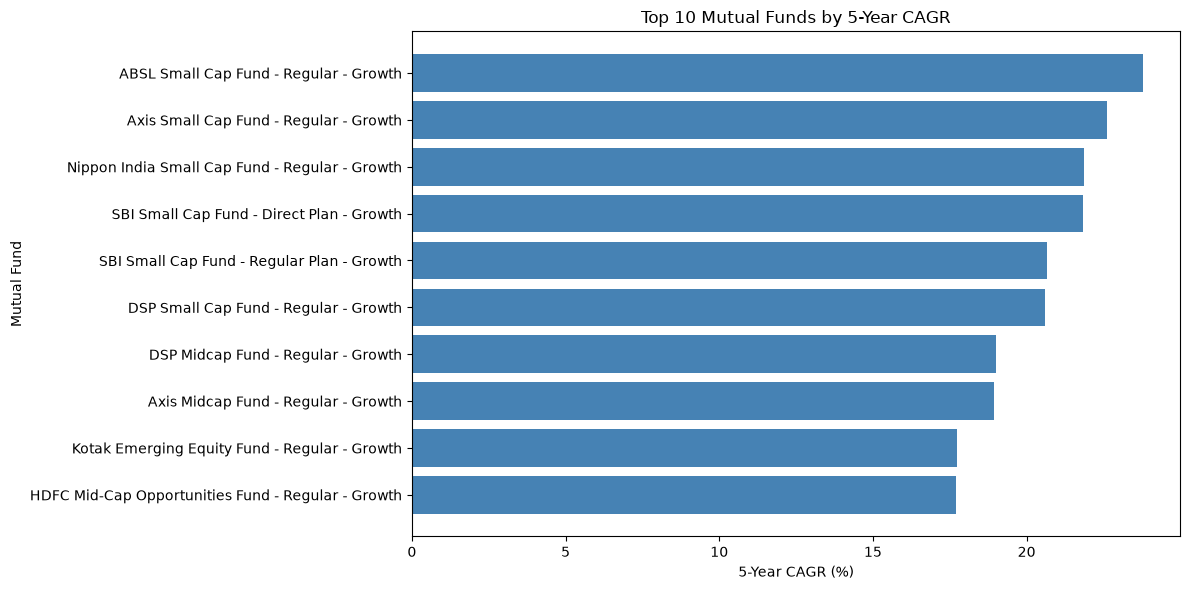

In [26]:
import matplotlib.pyplot as plt

# Top 10 funds based on 5-year return
top10 = performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["return_5yr_pct"],
    color="steelblue"
)

plt.xlabel("5-Year CAGR (%)")
plt.ylabel("Mutual Fund")
plt.title("Top 10 Mutual Funds by 5-Year CAGR")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../reports/charts/top10_cagr.png")

plt.show()

### Observation

The comparison shows that small-cap mutual funds achieved the highest 5-year CAGR among the selected schemes. Equity-oriented funds consistently outperformed debt-oriented funds over the long term, demonstrating stronger growth potential despite higher market volatility.

In [27]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


## 5. Sharpe Ratio Analysis

In [28]:
import pandas as pd
import numpy as np

# Load NAV history
nav = pd.read_csv("../data/raw/02_nav_history.csv")

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Risk-free rate (6.5% annually)
rf = 0.065 / 252

# Calculate Sharpe Ratio
sharpe = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(lambda x: ((x.mean() - rf) / x.std()) * np.sqrt(252))
       .reset_index()
)

sharpe.columns = ["amfi_code", "Sharpe_Ratio"]

sharpe.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [29]:
# Load fund master
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

# Merge Sharpe Ratio with fund names
sharpe.columns
# Rank funds
sharpe = sharpe.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

# Show Top 10
sharpe.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [33]:
print(sharpe.columns)

Index(['amfi_code', 'Sharpe_Ratio'], dtype='str')


In [34]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [35]:
sharpe = pd.merge(
    sharpe,
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [36]:
print(sharpe.columns)

Index(['amfi_code', 'Sharpe_Ratio', 'scheme_name'], dtype='str')


## 6. Top 10 Funds by Sharpe Ratio

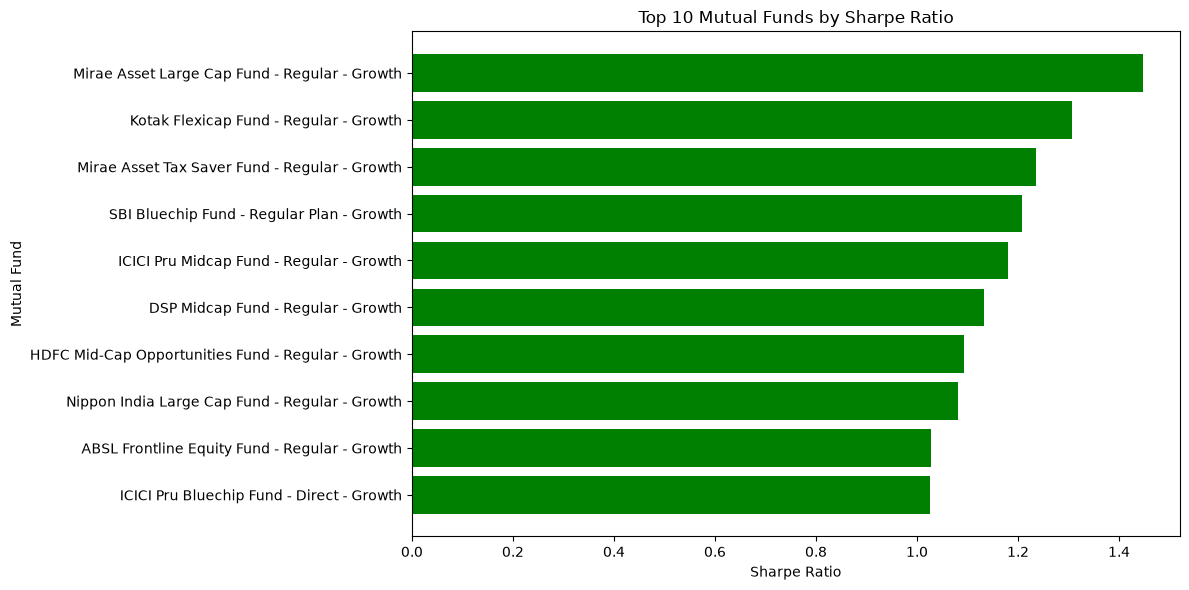

In [37]:
import matplotlib.pyplot as plt

top10 = sharpe.head(10)

plt.figure(figsize=(12,6))

plt.barh(top10["scheme_name"], top10["Sharpe_Ratio"], color="green")

plt.xlabel("Sharpe Ratio")
plt.ylabel("Mutual Fund")
plt.title("Top 10 Mutual Funds by Sharpe Ratio")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../reports/charts/sharpe_ratio.png")

plt.show()

### Observation

The Sharpe Ratio ranking shows that Mirae Asset Large Cap Fund and Kotak Flexicap Fund delivered the best risk-adjusted returns among the evaluated schemes. Higher Sharpe Ratios indicate more efficient returns for the level of risk undertaken.

## 7. Sortino Ratio Analysis

In [39]:
# Calculate Sortino Ratio
sortino = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(lambda x: ((x.mean() - rf) / x[x < 0].std()) * np.sqrt(252))
       .reset_index()
)

sortino.columns = ["amfi_code", "Sortino_Ratio"]

# Merge with fund names
sortino = sortino.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Rank funds
sortino = sortino.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino.head(10)

,amfi_code,Sortino_Ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [40]:
sortino.to_csv("../reports/sortino_ratio.csv", index=False)

print("Sortino Ratio saved successfully!")

Sortino Ratio saved successfully!


## 8. Top 10 Funds by Sortino Ratio

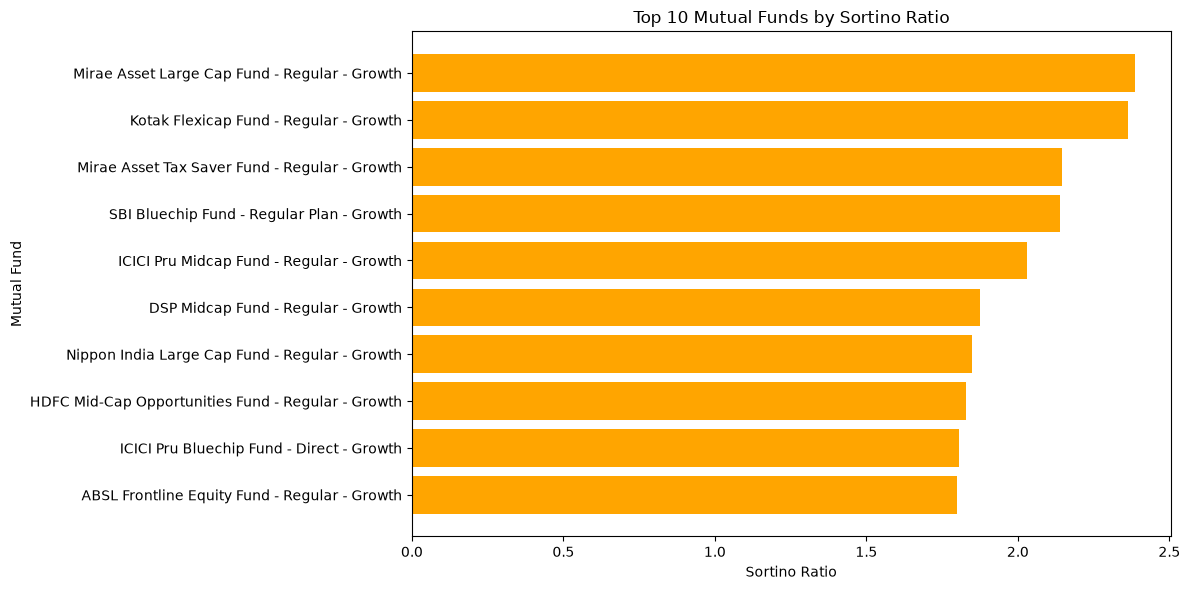

In [41]:
import matplotlib.pyplot as plt

top10 = sortino.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Sortino_Ratio"],
    color="orange"
)

plt.xlabel("Sortino Ratio")
plt.ylabel("Mutual Fund")
plt.title("Top 10 Mutual Funds by Sortino Ratio")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../reports/charts/sortino_ratio.png")

plt.show()

### Observation

The Sortino Ratio focuses only on downside risk, making it a better measure of risk-adjusted performance during negative market movements. Mirae Asset Large Cap Fund and Kotak Flexicap Fund achieved the highest Sortino Ratios, indicating strong returns with comparatively lower downside volatility.

In [42]:
import pandas as pd

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


## 9. Alpha & Beta Analysis

In [43]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Load benchmark data
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

# Convert dates
benchmark["date"] = pd.to_datetime(benchmark["date"])
nav["date"] = pd.to_datetime(nav["date"])

# Keep only NIFTY100
benchmark = benchmark[benchmark["index_name"] == "NIFTY100"]

# Calculate benchmark daily returns
benchmark = benchmark.sort_values("date")
benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["fund_return"] = fund_data["nav"].pct_change()

    merged = pd.merge(
        fund_data,
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["fund_return"]
        )

        alpha = intercept * 252
        beta = slope

        results.append([fund, alpha, beta])

alpha_beta = pd.DataFrame(
    results,
    columns=["amfi_code", "Alpha", "Beta"]
)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [44]:
# Load fund master
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

# Merge with Alpha & Beta
alpha_beta = alpha_beta.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Show top rows
alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [45]:
alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)

print("Alpha & Beta CSV saved successfully!")

Alpha & Beta CSV saved successfully!


## 10. Alpha vs Beta Analysis

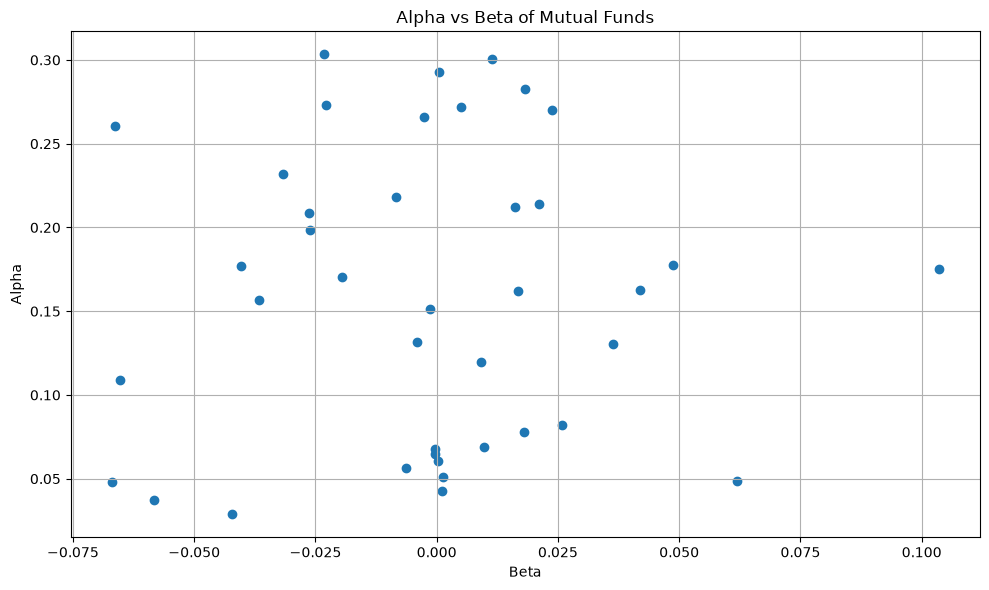

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(alpha_beta["Beta"], alpha_beta["Alpha"])

plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("Alpha vs Beta of Mutual Funds")

plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/charts/alpha_beta_scatter.png")

plt.show()

### Observation

The Alpha vs Beta scatter plot shows the relationship between a fund's excess return (Alpha) and its market sensitivity (Beta). Funds with higher Alpha indicate better performance than expected for their level of market risk, while Beta reflects how closely a fund moves with the benchmark index.

## 11. Maximum Drawdown Analysis

In [47]:
import pandas as pd

# Load NAV data
nav = pd.read_csv("../data/raw/02_nav_history.csv")

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund].copy()

    # Running maximum NAV
    temp["Running_Max"] = temp["nav"].cummax()

    # Drawdown
    temp["Drawdown"] = (temp["nav"] / temp["Running_Max"]) - 1

    max_dd = temp["Drawdown"].min()

    results.append([fund, max_dd])

drawdown = pd.DataFrame(
    results,
    columns=["amfi_code", "Maximum_Drawdown"]
)

drawdown.head()

,amfi_code,Maximum_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [48]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

drawdown = drawdown.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

drawdown = drawdown.sort_values(
    by="Maximum_Drawdown"
)

drawdown.head(10)

,amfi_code,Maximum_Drawdown,scheme_name
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,Axis Bluechip Fund - Direct - Growth


In [49]:
drawdown.to_csv("../reports/maximum_drawdown.csv", index=False)

print("Maximum Drawdown CSV saved successfully!")

Maximum Drawdown CSV saved successfully!


## 12. Maximum Drawdown Chart

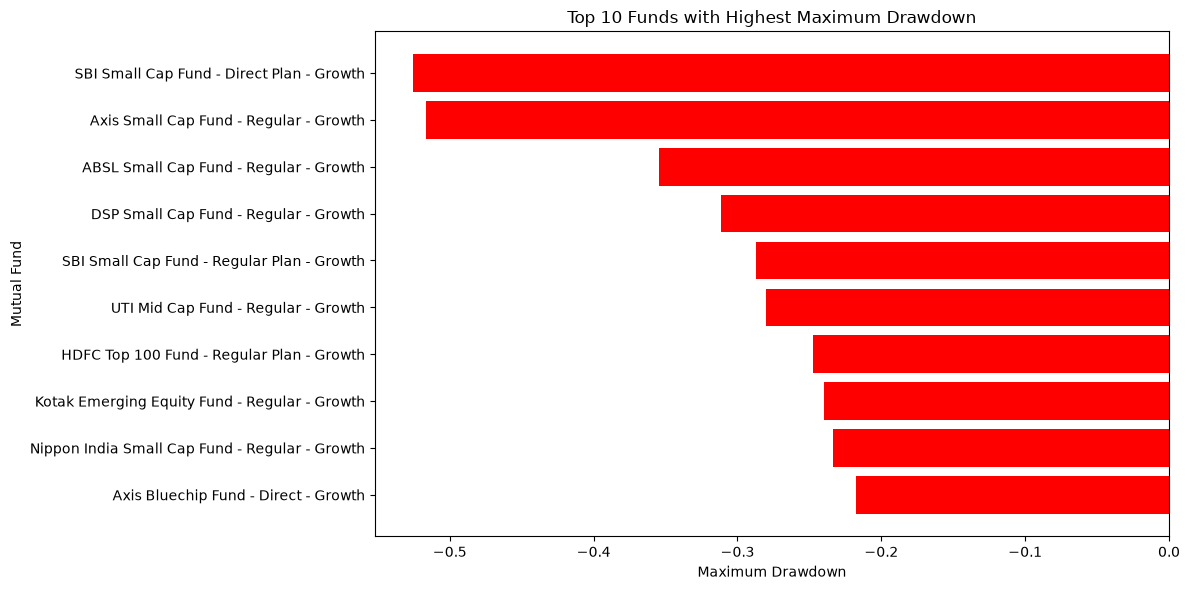

In [50]:
import matplotlib.pyplot as plt

top10 = drawdown.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Maximum_Drawdown"],
    color="red"
)

plt.xlabel("Maximum Drawdown")
plt.ylabel("Mutual Fund")
plt.title("Top 10 Funds with Highest Maximum Drawdown")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../reports/charts/maximum_drawdown.png")

plt.show()

### Observation

Maximum Drawdown measures the largest decline from a fund's peak NAV. Funds with smaller drawdowns generally demonstrate better downside protection during market corrections, while larger drawdowns indicate higher historical downside risk.

## 13. Fund Scorecard

In [51]:
# Load performance data
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

# Merge all metrics
scorecard = performance.merge(
    sharpe[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Sharpe_Ratio,Alpha,Maximum_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.29,14.0,-21.70,14288,1.54,4,Moderate,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1.29,14.0,-24.43,1231,0.66,3,Moderate,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.35,25.0,-13.35,19259,1.43,5,Very High,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,1.67,25.0,-24.78,36061,0.72,4,Very High,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,2.11,4.0,-2.30,24101,0.77,5,Low,-0.226575,0.056209,-0.043287


In [52]:
# Ranking
scorecard["Return_Rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)
scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(ascending=False)

# Composite Score
scorecard["Fund_Score"] = (
    scorecard["Return_Rank"] * 0.30 +
    scorecard["Sharpe_Rank"] * 0.25 +
    scorecard["Alpha_Rank"] * 0.20 +
    scorecard["Expense_Rank"] * 0.15 +
    scorecard["Drawdown_Rank"] * 0.10
)

# Convert to 0–100 scale
scorecard["Fund_Score"] = (
    100 * (scorecard["Fund_Score"].max() - scorecard["Fund_Score"])
    / (scorecard["Fund_Score"].max() - scorecard["Fund_Score"].min())
)

scorecard = scorecard.sort_values(
    by="Fund_Score",
    ascending=False
)

scorecard[
    ["scheme_name", "Fund_Score"]
].head(10)

,scheme_name,Fund_Score
12,ICICI Pru Midcap Fund - Regular - Growth,100.000000
22,Kotak Flexicap Fund - Regular - Growth,98.143852
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,93.039443
2,SBI Small Cap Fund - Regular Plan - Growth,91.879350
34,Mirae Asset Large Cap Fund - Regular - Growth,90.719258
39,DSP Small Cap Fund - Regular - Growth,80.858469
38,DSP Midcap Fund - Regular - Growth,78.190255
11,ICICI Pru Bluechip Fund - Direct - Growth,76.334107
26,Axis Midcap Fund - Regular - Growth,74.941995
36,Mirae Asset Tax Saver Fund - Regular - Growth,67.401392


In [54]:
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


## 14. Top 10 Fund Scorecard

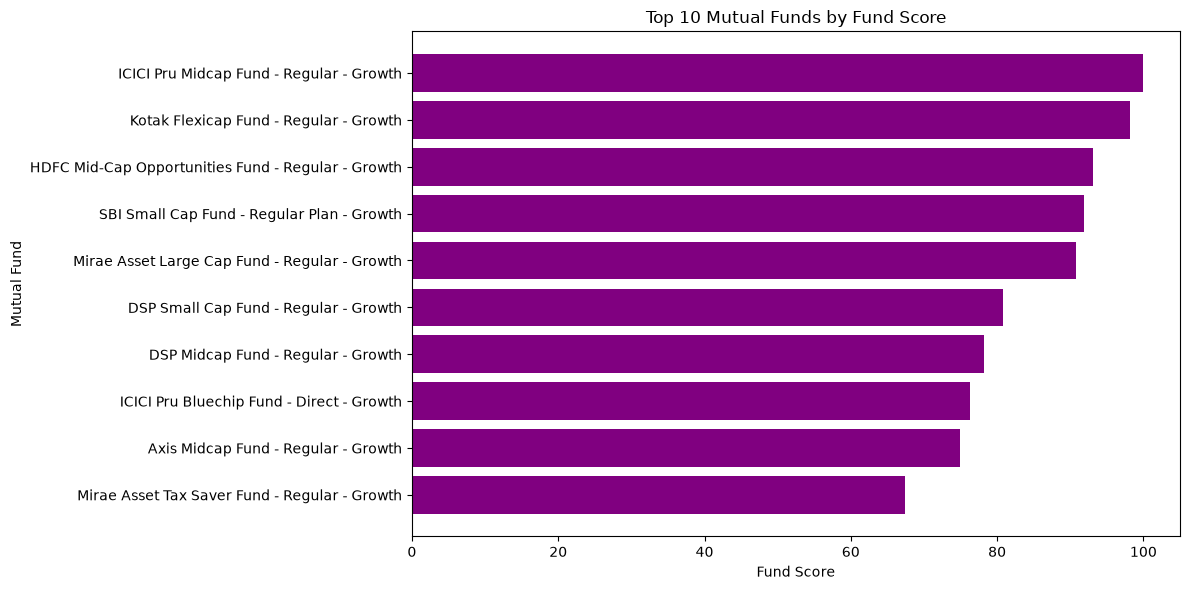

In [55]:
import matplotlib.pyplot as plt

top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Fund_Score"],
    color="purple"
)

plt.xlabel("Fund Score")
plt.ylabel("Mutual Fund")
plt.title("Top 10 Mutual Funds by Fund Score")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../reports/charts/fund_scorecard.png")

plt.show()

### Observation

The composite Fund Score ranks mutual funds using multiple performance indicators, including 3-year returns, Sharpe Ratio, Alpha, expense ratio, and Maximum Drawdown. Funds with higher scores demonstrate a balanced combination of strong returns, efficient risk management, and lower costs.

## 15. Benchmark Comparison & Tracking Error

In [56]:
import pandas as pd

# Load NAV history
nav = pd.read_csv("../data/raw/02_nav_history.csv")

# Load benchmark
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Display first few rows
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [57]:
# Top 5 funds from scorecard
top5_codes = scorecard.head(5)["amfi_code"].tolist()

# Filter NAV data
top5_nav = nav[nav["amfi_code"].isin(top5_codes)].copy()

# Calculate daily returns
top5_nav = top5_nav.sort_values(["amfi_code", "date"])
top5_nav["daily_return"] = top5_nav.groupby("amfi_code")["nav"].pct_change()

top5_nav.head()

,amfi_code,date,nav,daily_return
8050,100033,2022-01-03,107.3758,NaN
8051,100033,2022-01-04,105.9447,-0.013328
8052,100033,2022-01-05,105.4800,-0.004386
8053,100033,2022-01-06,104.9350,-0.005167
8054,100033,2022-01-07,104.3318,-0.005748


In [58]:
# Keep only NIFTY50
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()

# Daily return
nifty50 = nifty50.sort_values("date")
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

nifty50.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [59]:
tracking_error = []

for fund in top5_codes:

    fund_data = top5_nav[top5_nav["amfi_code"] == fund]

    merged = pd.merge(
        fund_data,
        nifty50[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    te = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * (252 ** 0.5)
    )

    tracking_error.append([fund, te])

tracking_error = pd.DataFrame(
    tracking_error,
    columns=["amfi_code", "Tracking_Error"]
)

tracking_error

,amfi_code,Tracking_Error
0,120505,0.233124
1,120843,0.205148
2,100033,0.229755
3,119598,0.278033
4,148567,0.193996


In [60]:
tracking_error = tracking_error.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

tracking_error

,amfi_code,Tracking_Error,scheme_name
0,120505,0.233124,ICICI Pru Midcap Fund - Regular - Growth
1,120843,0.205148,Kotak Flexicap Fund - Regular - Growth
2,100033,0.229755,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,119598,0.278033,SBI Small Cap Fund - Regular Plan - Growth
4,148567,0.193996,Mirae Asset Large Cap Fund - Regular - Growth


In [61]:
tracking_error.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error saved successfully!")

Tracking Error saved successfully!


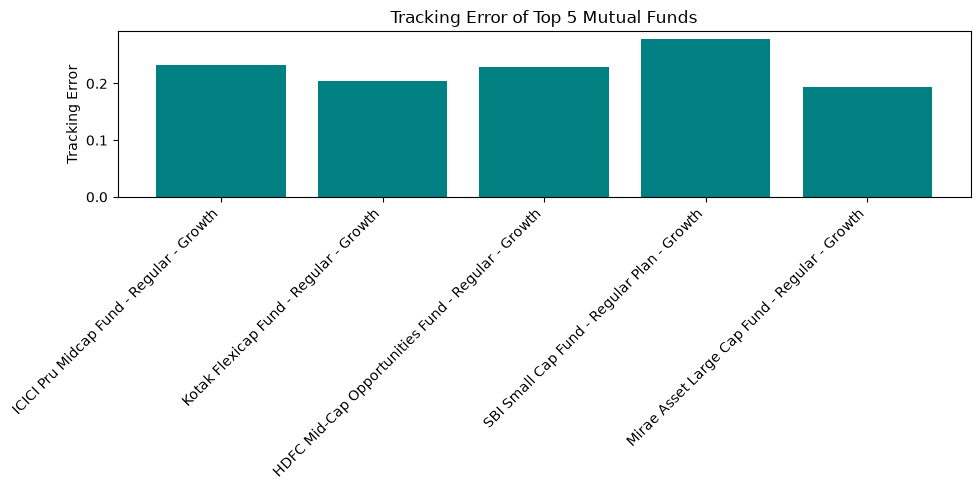

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    tracking_error["scheme_name"],
    tracking_error["Tracking_Error"],
    color="teal"
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Tracking Error")

plt.title("Tracking Error of Top 5 Mutual Funds")

plt.tight_layout()

plt.savefig("../reports/charts/tracking_error.png")

plt.show()

In [ ]:
### Observation

Tracking Error measures how closely a mutual fund follows its benchmark index. Lower tracking error indicates that the fund closely tracks the benchmark, while higher values indicate greater deviation in performance.